# 1. Data Preparation, EDA and Preliminary Tests

This notebook prepares the raw VN30 index data for volatility modeling and conducts preliminary time series analysis.

The main objectives are:

1. Load and clean the raw VN30 data.
2. Transform the VN30 closing index into daily log-returns.
3. Explore the behavior of VN30 returns.
4. Check stationarity and volatility clustering.
5. Test for ARCH effects before fitting GARCH-family models.

In [22]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.6f}".format)

In [23]:
cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "VN30_2015_2026.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "vn30_returns.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_PATH)
print("Processed data path:", PROCESSED_PATH)

Project root: e:\TimeSeries\vn30-garch-volatility
Raw data path: e:\TimeSeries\vn30-garch-volatility\data\raw\VN30_2015_2026.csv
Processed data path: e:\TimeSeries\vn30-garch-volatility\data\processed\vn30_returns.csv


## 1.1 Load Raw Data

The raw dataset contains daily VN30 index information. The most important variable for this project is the closing index level, which will later be transformed into log-return.

In [24]:
raw = pd.read_csv(RAW_PATH)

raw_overview = pd.DataFrame(
    {
        "Number of rows": [raw.shape[0]],
        "Number of columns": [raw.shape[1]],
        "Column names": [", ".join(raw.columns.astype(str))],
        "Duplicated rows": [raw.duplicated().sum()],
        "Total missing values": [raw.isna().sum().sum()],
    }
)

raw_overview

,Number of rows,Number of columns,Column names,Duplicated rows,Total missing values
0,2824,7,"Ngày, Lần cuối, Mở, Cao, Thấp, KL, % Thay đổi",0,0


## 1.2 Data Cleaning

The original columns are renamed into English names for easier modeling.

Original columns:

- `Ngày`: trading date
- `Lần cuối`: closing index level
- `Mở`: opening index level
- `Cao`: highest index level
- `Thấp`: lowest index level
- `KL`: trading volume
- `% Thay đổi`: daily percentage change reported in the raw source

The data are then sorted chronologically from oldest to newest.

In [25]:
df = raw.copy()

df = df.rename(
    columns={
        "Ngày": "date",
        "Lần cuối": "close",
        "Mở": "open",
        "Cao": "high",
        "Thấp": "low",
        "KL": "volume",
        "% Thay đổi": "raw_change_pct",
    }
)

df.head()

,date,close,open,high,low,volume,raw_change_pct
0,29/04/2026,"2,022.75","2,041.40","2,052.48","2,007.85",239.35M,-0.91%
1,28/04/2026,"2,041.40","2,011.42","2,045.19","2,008.70",240.48M,1.49%
2,24/04/2026,"2,011.42","2,024.74","2,035.48","2,001.22",248.43M,-0.66%
3,23/04/2026,"2,024.74","2,025.41","2,047.68","2,014.71",396.53M,-0.03%
4,22/04/2026,"2,025.41","2,007.08","2,029.47","1,990.45",240.46M,0.91%


In [26]:
def clean_price(value):
    """
    Convert price strings such as '2,022.75' into floats.
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace(",", "").strip()
    return pd.to_numeric(value, errors="coerce")


def clean_percent(value):
    """
    Convert percent strings such as '-0.91%' into floats.
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace("%", "").replace(",", "").strip()
    return pd.to_numeric(value, errors="coerce")


def clean_volume(value):
    """
    Convert volume strings such as '239.35M' into numeric values.
    Supports K, M, B suffixes.
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace(",", "").strip()
    
    if value.endswith("K"):
        return pd.to_numeric(value[:-1], errors="coerce") * 1_000
    if value.endswith("M"):
        return pd.to_numeric(value[:-1], errors="coerce") * 1_000_000
    if value.endswith("B"):
        return pd.to_numeric(value[:-1], errors="coerce") * 1_000_000_000
    
    return pd.to_numeric(value, errors="coerce")

In [27]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

for col in ["close", "open", "high", "low"]:
    df[col] = df[col].apply(clean_price)

df["volume"] = df["volume"].apply(clean_volume)
df["raw_change_pct"] = df["raw_change_pct"].apply(clean_percent)

df = (
    df.dropna(subset=["date", "close"])
    .sort_values("date")
    .drop_duplicates(subset=["date"], keep="last")
    .reset_index(drop=True)
)

df = df[df["close"] > 0].copy()

df.head()

,date,close,open,high,low,volume,raw_change_pct
0,2015-01-05,599.690000,600.480000,604.990000,599.690000,"50,120.000000",-0.330000
1,2015-01-06,606.370000,594.370000,606.450000,593.460000,"44,820.000000",1.110000
2,2015-01-07,607.650000,606.490000,611.780000,606.490000,"52,990.000000",0.210000
3,2015-01-08,606.850000,607.520000,609.850000,605.370000,"35,330.000000",-0.130000
4,2015-01-09,618.410000,608.260000,619.520000,608.260000,"54,770.000000",1.900000


In [28]:
cleaned_overview = pd.DataFrame(
    {
        "Number of observations": [len(df)],
        "Start date": [df["date"].min()],
        "End date": [df["date"].max()],
        "Missing close values": [df["close"].isna().sum()],
        "Duplicated dates": [df["date"].duplicated().sum()],
        "Minimum close": [df["close"].min()],
        "Maximum close": [df["close"].max()],
    }
)

cleaned_overview

,Number of observations,Start date,End date,Missing close values,Duplicated dates,Minimum close,Maximum close
0,2824,2015-01-05,2026-04-29,0,0,538.530000,"2,096.760000"


In [29]:
df["log_close"] = np.log(df["close"])

df["log_return"] = df["log_close"].diff()
df["return_pct"] = df["log_return"] * 100

df["simple_return_pct"] = df["close"].pct_change() * 100

df["squared_return"] = df["return_pct"] ** 2
df["abs_return"] = df["return_pct"].abs()

processed = df.dropna().reset_index(drop=True)

processed.head()

,date,close,open,high,low,volume,raw_change_pct,log_close,log_return,return_pct,simple_return_pct,squared_return,abs_return
0,2015-01-06,606.370000,594.370000,606.450000,593.460000,"44,820.000000",1.110000,6.407490,0.011078,1.107751,1.113909,1.227111,1.107751
1,2015-01-07,607.650000,606.490000,611.780000,606.490000,"52,990.000000",0.210000,6.409599,0.002109,0.210870,0.211092,0.044466,0.210870
2,2015-01-08,606.850000,607.520000,609.850000,605.370000,"35,330.000000",-0.130000,6.408282,-0.001317,-0.131741,-0.131655,0.017356,0.131741
3,2015-01-09,618.410000,608.260000,619.520000,608.260000,"54,770.000000",1.900000,6.427152,0.018870,1.887002,1.904919,3.560778,1.887002
4,2015-01-12,615.730000,618.040000,624.180000,615.490000,"74,160.000000",-0.430000,6.422809,-0.004343,-0.434311,-0.433369,0.188626,0.434311


In [30]:
processed.to_csv(PROCESSED_PATH, index=False)

print(f"Processed data saved to: {PROCESSED_PATH}")
print(f"Number of observations: {len(processed)}")
print(f"Date range: {processed['date'].min().date()} to {processed['date'].max().date()}")

Processed data saved to: e:\TimeSeries\vn30-garch-volatility\data\processed\vn30_returns.csv
Number of observations: 2823
Date range: 2015-01-06 to 2026-04-29


## 1.3 Exploratory Data Analysis

This section visualizes the VN30 closing index, daily return, return distribution, and rolling volatility.

The purpose is to identify common financial time series features such as:

- non-stationarity in index level,
- return fluctuations around zero,
- fat-tailed return distribution,
- volatility clustering.

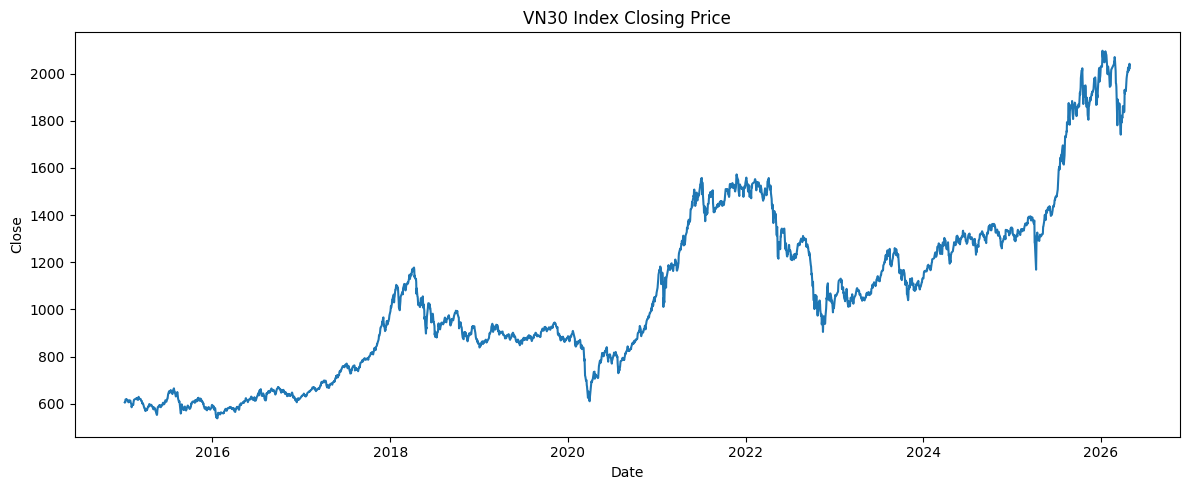

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(processed["date"], processed["close"])
plt.title("VN30 Index Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_vn30_close.png", dpi=300)
plt.show()

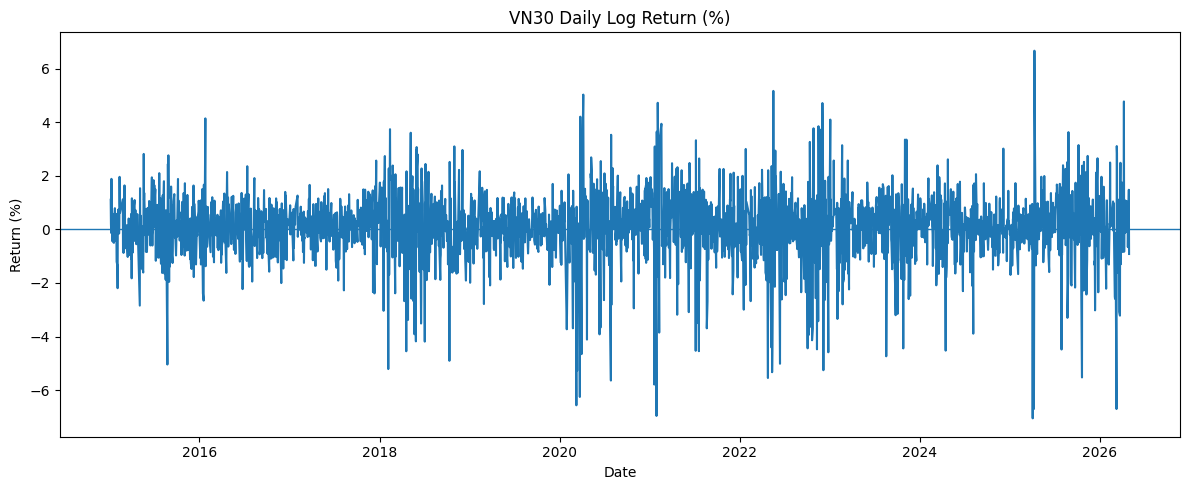

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(processed["date"], processed["return_pct"])
plt.axhline(0, linewidth=1)
plt.title("VN30 Daily Log Return (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_vn30_return_pct.png", dpi=300)
plt.show()

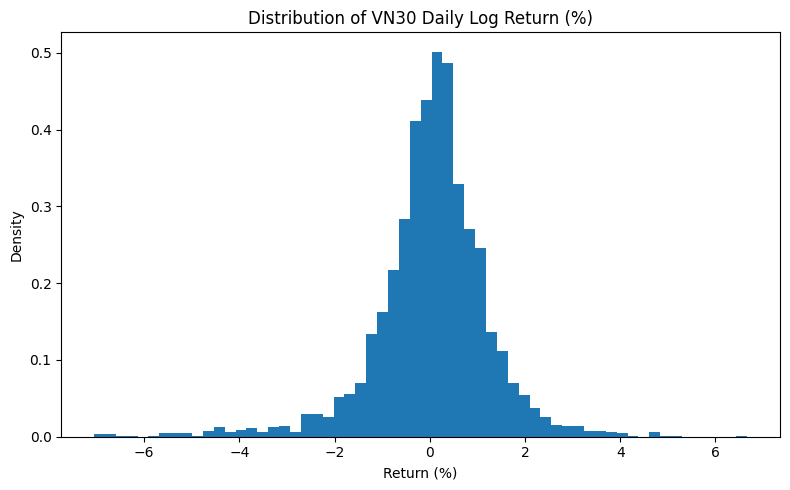

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(processed["return_pct"], bins=60, density=True)
plt.title("Distribution of VN30 Daily Log Return (%)")
plt.xlabel("Return (%)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_vn30_return_histogram.png", dpi=300)
plt.show()

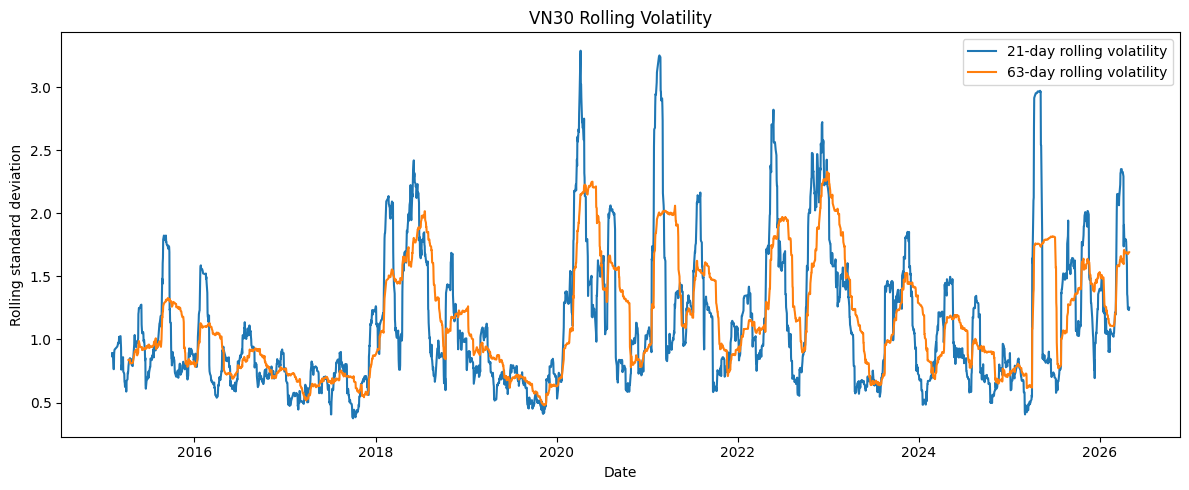

In [34]:
processed["rolling_vol_21"] = processed["return_pct"].rolling(window=21).std()
processed["rolling_vol_63"] = processed["return_pct"].rolling(window=63).std()

plt.figure(figsize=(12, 5))
plt.plot(processed["date"], processed["rolling_vol_21"], label="21-day rolling volatility")
plt.plot(processed["date"], processed["rolling_vol_63"], label="63-day rolling volatility")
plt.title("VN30 Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling standard deviation")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_vn30_rolling_volatility.png", dpi=300)
plt.show()

In [35]:
summary_stats = pd.DataFrame(
    {
        "Mean": [processed["return_pct"].mean()],
        "Median": [processed["return_pct"].median()],
        "Std. Dev.": [processed["return_pct"].std()],
        "Minimum": [processed["return_pct"].min()],
        "Maximum": [processed["return_pct"].max()],
        "Skewness": [processed["return_pct"].skew()],
        "Kurtosis": [processed["return_pct"].kurtosis()],
        "Observations": [processed["return_pct"].count()],
    },
    index=["VN30 daily log-return (%)"],
)

summary_stats.to_csv(TABLE_DIR / "01_summary_statistics_return.csv")

summary_stats

,Mean,Median,Std. Dev.,Minimum,Maximum,Skewness,Kurtosis,Observations
VN30 daily log-return (%),0.043068,0.120097,1.230197,-7.052227,6.670048,-0.818594,4.867560,2823


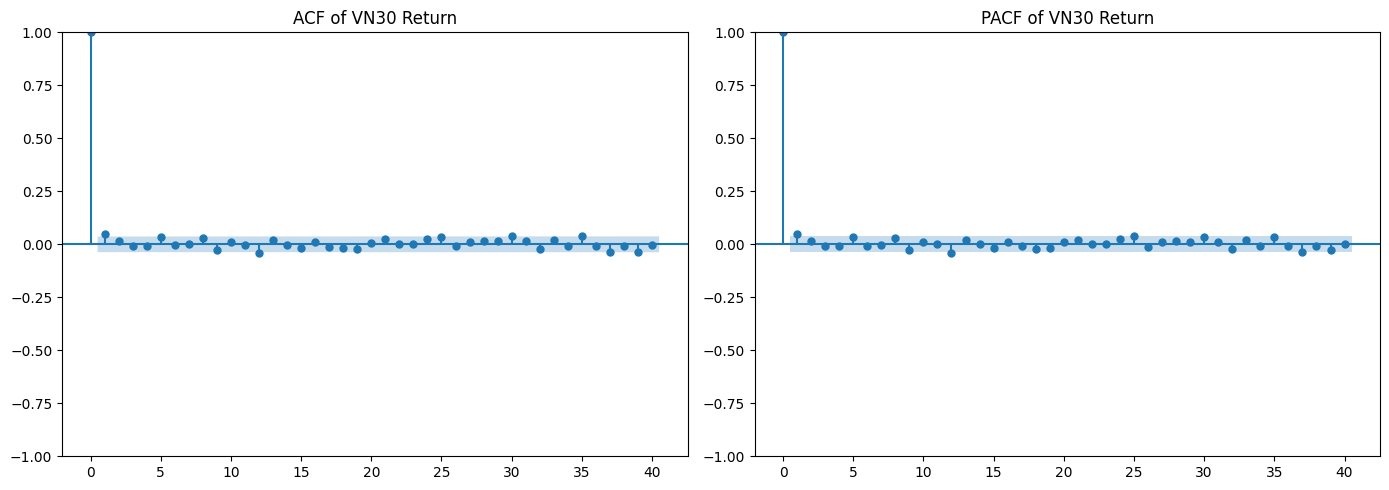

In [36]:
returns = processed["return_pct"].dropna()

max_lags = min(40, len(returns) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(returns, lags=max_lags, ax=axes[0])
axes[0].set_title("ACF of VN30 Return")

plot_pacf(returns, lags=max_lags, ax=axes[1], method="ywm")
axes[1].set_title("PACF of VN30 Return")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_acf_pacf_return.png", dpi=300)
plt.show()

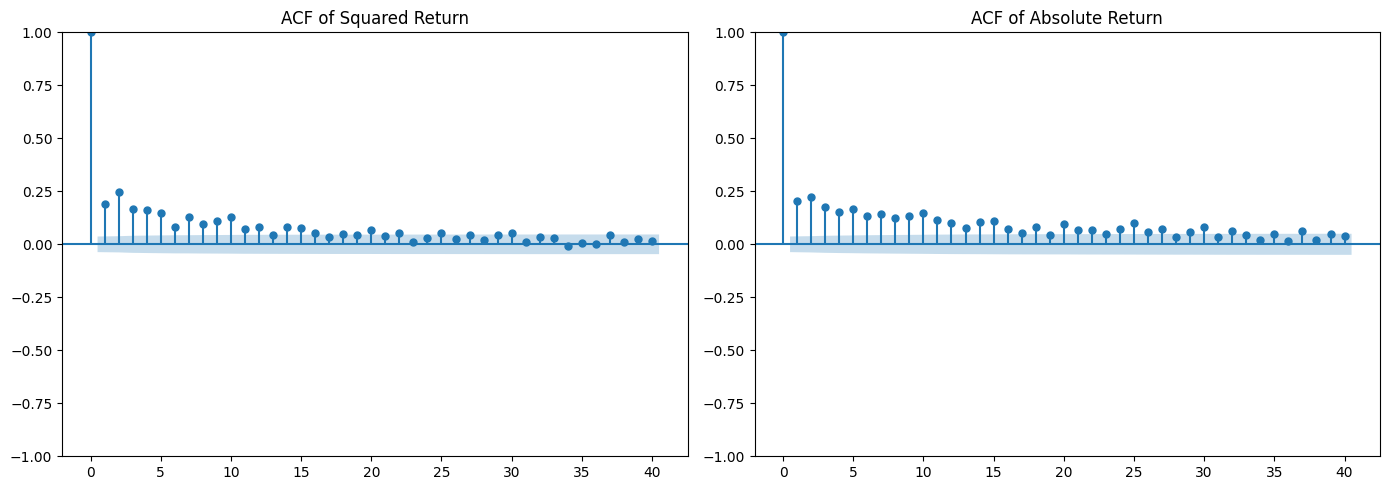

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(processed["squared_return"].dropna(), lags=max_lags, ax=axes[0])
axes[0].set_title("ACF of Squared Return")

plot_acf(processed["abs_return"].dropna(), lags=max_lags, ax=axes[1])
axes[1].set_title("ACF of Absolute Return")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_acf_squared_abs_return.png", dpi=300)
plt.show()

## 1.4 Stationarity and ARCH Effect Tests

This section conducts three groups of preliminary tests:

1. **ADF test**: checks whether the series is stationary.
2. **Ljung–Box test**: checks autocorrelation in returns and squared returns.
3. **ARCH-LM test**: checks whether lagged squared shocks explain current volatility.

These tests provide statistical motivation for using GARCH-family models.

In [38]:
def run_adf_test(series, name, regression="c"):
    """
    Run Augmented Dickey-Fuller test and return a one-row DataFrame.
    
    regression:
    - 'c': constant
    - 'ct': constant and trend
    """
    series = pd.Series(series).dropna()
    
    result = adfuller(series, regression=regression, autolag="AIC")
    
    return pd.DataFrame(
        {
            "Series": [name],
            "ADF statistic": [result[0]],
            "p-value": [result[1]],
            "Used lag": [result[2]],
            "Observations": [result[3]],
            "1% critical value": [result[4]["1%"]],
            "5% critical value": [result[4]["5%"]],
            "10% critical value": [result[4]["10%"]],
        }
    )

In [39]:
adf_close = run_adf_test(
    processed["close"],
    name="VN30 close",
    regression="ct",
)

adf_return = run_adf_test(
    processed["return_pct"],
    name="VN30 return (%)",
    regression="c",
)

adf_results = pd.concat([adf_close, adf_return], ignore_index=True)

adf_results.to_csv(TABLE_DIR / "02_adf_tests.csv", index=False)

adf_results

,Series,ADF statistic,p-value,Used lag,Observations,1% critical value,5% critical value,10% critical value
0,VN30 close,-1.479771,0.835956,12,2810,-3.961995,-3.412054,-3.127971
1,VN30 return (%),-50.689610,0.000000,0,2822,-3.432669,-2.862565,-2.567315


In [40]:
ljung_return = acorr_ljungbox(
    processed["return_pct"],
    lags=[10, 20],
    return_df=True,
).reset_index()

ljung_return = ljung_return.rename(columns={"index": "Lag"})
ljung_return["Series"] = "Return"

ljung_squared = acorr_ljungbox(
    processed["squared_return"],
    lags=[10, 20],
    return_df=True,
).reset_index()

ljung_squared = ljung_squared.rename(columns={"index": "Lag"})
ljung_squared["Series"] = "Squared return"

ljung_results = pd.concat([ljung_return, ljung_squared], ignore_index=True)

ljung_results = ljung_results[
    ["Series", "Lag", "lb_stat", "lb_pvalue"]
]

ljung_results.to_csv(TABLE_DIR / "03_ljung_box_tests.csv", index=False)

ljung_results

,Series,Lag,lb_stat,lb_pvalue
0,Return,10,15.468273,0.115899
1,Return,20,25.611733,0.179021
2,Squared return,10,658.226474,0.000000
3,Squared return,20,769.387258,0.000000


In [41]:
demeaned_returns = processed["return_pct"] - processed["return_pct"].mean()

arch_lm_result = het_arch(demeaned_returns.dropna(), nlags=10)

arch_lm_table = pd.DataFrame(
    {
        "Test": ["ARCH-LM"],
        "Lags": [10],
        "LM statistic": [arch_lm_result[0]],
        "LM p-value": [arch_lm_result[1]],
        "F statistic": [arch_lm_result[2]],
        "F p-value": [arch_lm_result[3]],
    }
)

arch_lm_table.to_csv(TABLE_DIR / "04_arch_lm_test.csv", index=False)

arch_lm_table

,Test,Lags,LM statistic,LM p-value,F statistic,F p-value
0,ARCH-LM,10,304.757531,0.000000,34.044978,0.000000


In [42]:
test_summary = pd.DataFrame(
    {
        "Test": [
            "ADF test on VN30 close",
            "ADF test on VN30 return",
            "Ljung-Box on return, lag 20",
            "Ljung-Box on squared return, lag 20",
            "ARCH-LM test, lag 10",
        ],
        "Statistic": [
            adf_results.loc[adf_results["Series"] == "VN30 close", "ADF statistic"].iloc[0],
            adf_results.loc[adf_results["Series"] == "VN30 return (%)", "ADF statistic"].iloc[0],
            ljung_results.loc[
                (ljung_results["Series"] == "Return") & (ljung_results["Lag"] == 20),
                "lb_stat",
            ].iloc[0],
            ljung_results.loc[
                (ljung_results["Series"] == "Squared return") & (ljung_results["Lag"] == 20),
                "lb_stat",
            ].iloc[0],
            arch_lm_table["LM statistic"].iloc[0],
        ],
        "p-value": [
            adf_results.loc[adf_results["Series"] == "VN30 close", "p-value"].iloc[0],
            adf_results.loc[adf_results["Series"] == "VN30 return (%)", "p-value"].iloc[0],
            ljung_results.loc[
                (ljung_results["Series"] == "Return") & (ljung_results["Lag"] == 20),
                "lb_pvalue",
            ].iloc[0],
            ljung_results.loc[
                (ljung_results["Series"] == "Squared return") & (ljung_results["Lag"] == 20),
                "lb_pvalue",
            ].iloc[0],
            arch_lm_table["LM p-value"].iloc[0],
        ],
    }
)

test_summary.to_csv(TABLE_DIR / "05_preliminary_test_summary.csv", index=False)

test_summary

,Test,Statistic,p-value
0,ADF test on VN30 close,-1.479771,0.835956
1,ADF test on VN30 return,-50.689610,0.000000
2,"Ljung-Box on return, lag 20",25.611733,0.179021
3,"Ljung-Box on squared return, lag 20",769.387258,0.000000
4,"ARCH-LM test, lag 10",304.757531,0.000000
